In [1]:
import sys, os

sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("helper"))

from plot_utils import (
    pd,
    plt,
    save_figure,
    load_file,
    read_config_from_csv,
    list_runs,
    navy,
    LINE_STYLE,
    GRID_STYLE,
)

METRICS_DIR = "../metrics"
FIG_DIR = "../figures/evaluation/anonymity"
os.makedirs(FIG_DIR, exist_ok=True)

In [2]:
MU_VALUES = [0.02, 0.06, 0.10, 0.14, 0.20]


def per_run_aggregates(df):
    df = df[df.field.isin(["total_sent", "forwarded", "fragments_sent"])].copy()

    df["v"] = pd.to_numeric(df.value)
    df["t"] = (df.timestamp - df.timestamp.min()).dt.total_seconds()

    ordered_by_time = df.sort_values("t")

    # For each (node, field): last cumulative value and the time it was active.
    last_per_node_field = ordered_by_time.groupby(["node", "field"]).agg(
        v=("v", "last"), t_first=("t", "min"), t_last=("t", "max")
    )

    per_node = last_per_node_field["v"].unstack("field")
    active_span = (last_per_node_field["t_last"] - last_per_node_field["t_first"]).groupby("node").max()

    per_node["active"] = active_span
    per_node["covers"] = per_node["total_sent"] - per_node["forwarded"] - per_node["fragments_sent"]

    return per_node


mu_run_rows = []
for name, path in list_runs(os.path.join(METRICS_DIR, "b1_mu_sweep")):

    config = read_config_from_csv(path)
    mu_value = config.get("mix_mu")
    seed = int(name.rsplit("_seed_", 1)[1])

    df = load_file(path)
    per_node = per_run_aggregates(df)

    mu_run_rows.append(
        (
            mu_value,
            seed,
            float(per_node["covers"].mean()),
            float(per_node["fragments_sent"].mean()),
            float(per_node["active"].mean()),
        )
    )

df_cov = pd.DataFrame(mu_run_rows, columns=["mu", "seed", "covers_per_node", "real_per_node", "active_s"])
agg = (
    df_cov.groupby("mu")
    .agg(
        mean=("covers_per_node", "mean"),
        min=("covers_per_node", "min"),
        max=("covers_per_node", "max"),
        active=("active_s", "mean"),
        real=("real_per_node", "mean"),
    )
    .reset_index()
    .sort_values("mu")
)

agg["analytical"] = agg["active"] / agg["mu"] - agg["real"]

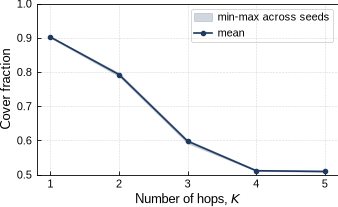

In [3]:
k_frac_rows = []

for name, path in list_runs(os.path.join(METRICS_DIR, "b1_k_sweep")):

    config = read_config_from_csv(path)
    K = config["max_hops"]

    df = load_file(path)
    per_node = per_run_aggregates(df)

    cover_fraction = (per_node["covers"] / (per_node["covers"] + per_node["fragments_sent"])).mean()

    k_frac_rows.append((K, float(cover_fraction)))

df_k_frac = pd.DataFrame(k_frac_rows, columns=["K", "frac"])

agg_k_frac = (
    df_k_frac.groupby("K")
    .agg(mean=("frac", "mean"), lo=("frac", "min"), hi=("frac", "max"))
    .reset_index()
    .sort_values("K")
)

fig, ax = plt.subplots(figsize=(3.46, 2.15))

ax.fill_between(
    agg_k_frac["K"], agg_k_frac["lo"], agg_k_frac["hi"], color=navy, alpha=0.2, label="min-max across seeds"
)

ax.plot(agg_k_frac["K"], agg_k_frac["mean"], marker="o", color=navy, markersize=3, label="mean", **LINE_STYLE)
ax.set_xlabel("Number of hops, $K$")
ax.set_ylabel("Cover fraction")

ax.set_ylim(0.5, 1.0)

ax.set_xticks(sorted(set(agg_k_frac["K"])))

ax.grid(**GRID_STYLE)
ax.legend(loc="upper right", framealpha=0.9)
fig.tight_layout()

save_figure(fig, f"{FIG_DIR}/cover_fraction_vs_k.pdf")

plt.show()